展开式： f(x) = 1.5x_1^2 + 1x_1x_2 + 1.0x_2^2 - 2x_1 - 1x_2 + 0
二次函数与优化
A = 
[[3 1]
 [1 2]]
b = [2 1]

最优解 x* = [0.6 0.2]
梯度在 x* 处: [0. 0.] (应为零)


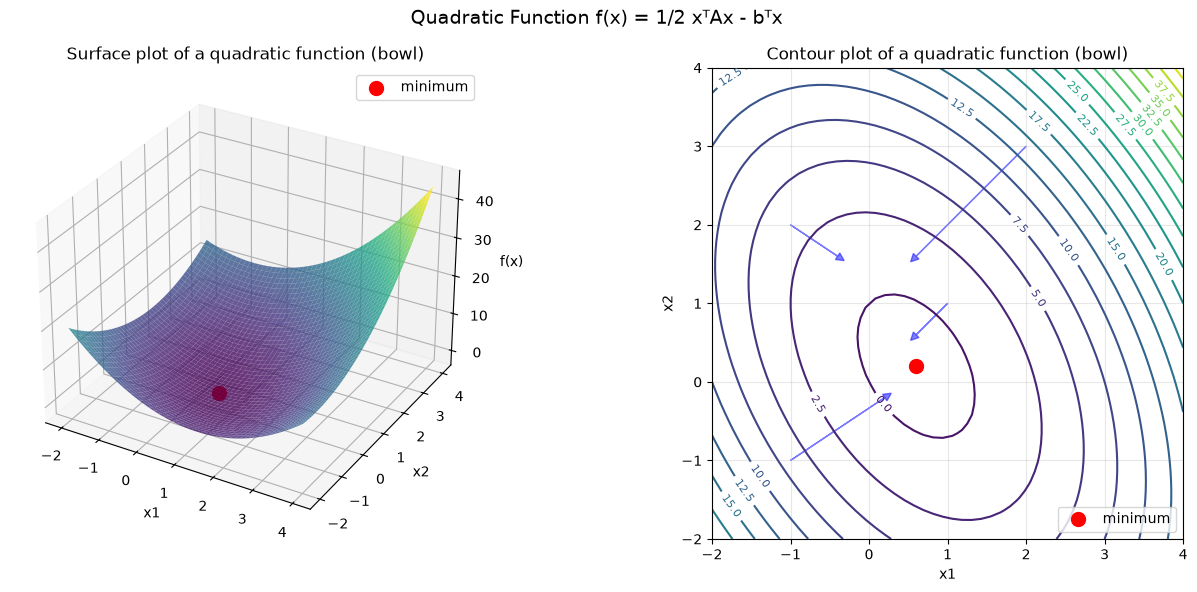


梯度下降：从初始点走到最小值
初始点: [3 3]
最小值点: [0.6 0.2]

一步梯度下降 (α=0.1):
  x1 = [2.  2.2]

10步梯度下降后: [0.50042738 0.436021  ]
离最优解的距离: 0.2562


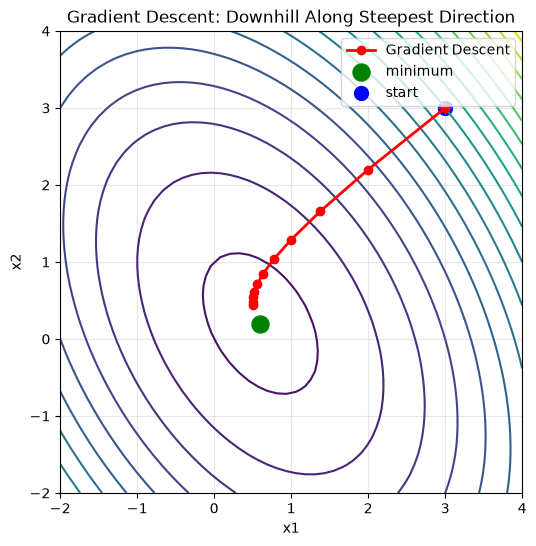

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---- 定义一个二次函数 f(x) = ½ x^T A x - b^T x ----
A = np.array([[3, 1], [1, 2]])  # 对称正定矩阵
b = np.array([2, 1])
c = 0
print(f"展开式： f(x) = {0.5*A[0, 0]}x_1^2 + {A[0, 1]}x_1x_2 + {0.5*A[1, 1]}x_2^2 - {b[0]}x_1 - {b[1]}x_2 + {c}")

print("=" * 60)
print("二次函数与优化")
print("=" * 60)
print(f"A = \n{A}")
print(f"b = {b}")

# ---- 计算梯度 ----
def grad_f(x):
    """∇f(x) = A x - b"""
    return A @ x - b

# ---- 求最小值点 ----
# 解 A x = b
x_star = np.linalg.solve(A, b)
print(f"\n最优解 x* = {x_star}")
print(f"梯度在 x* 处: {grad_f(x_star)} (应为零)")

# ---- 可视化 ----
# 在网格上计算函数值
x1 = np.linspace(-2, 4, 50)
x2 = np.linspace(-2, 4, 50)
X1, X2 = np.meshgrid(x1, x2)

Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        Z[i, j] = 0.5 * x.T @ A @ x - b.T @ x

fig = plt.figure(figsize=(14, 6))

# 3D 图
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax1.scatter(x_star[0], x_star[1], 0.5*x_star.T@A@x_star - b.T@x_star, 
           color='red', s=100, label='minimum')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x)')
ax1.set_title('Surface plot of a quadratic function (bowl)')
ax1.legend()

# 等高线图
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter(x_star[0], x_star[1], color='red', s=100, label='minimum')
# 画梯度方向（在几个点上）
for start in [[-1, -1], [1, 1], [2, 3], [-1, 2]]:
    g = grad_f(np.array(start))
    ax2.arrow(start[0], start[1], -g[0]*0.2, -g[1]*0.2, 
             head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.5)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
# ax2.set_title('等高线 + 梯度方向 (指向碗底)')
ax2.set_title('Contour plot of a quadratic function (bowl)')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

plt.suptitle('二次函数 f(x) = ½ xᵀAx - bᵀx', fontsize=14)
plt.suptitle('Quadratic Function f(x) = 1/2 xᵀAx - bᵀx', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 梯度下降的步长 ----
print("\n" + "=" * 60)
print("梯度下降：从初始点走到最小值")
print("=" * 60)

x0 = np.array([3, 3])
print(f"初始点: {x0}")
print(f"最小值点: {x_star}")

# 一步梯度下降：x1 = x0 - α ∇f(x0)
alpha = 0.1
x1 = x0 - alpha * grad_f(x0)
print(f"\n一步梯度下降 (α={alpha}):")
print(f"  x1 = {x1}")

# 多步梯度下降
x = x0.copy()
trajectory = [x.copy()]
for i in range(10):
    x = x - 0.1 * grad_f(x)
    trajectory.append(x.copy())
trajectory = np.array(trajectory)

print(f"\n10步梯度下降后: {trajectory[-1]}")
print(f"离最优解的距离: {np.linalg.norm(trajectory[-1] - x_star):.4f}")

# 在等高线图上画轨迹
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(X1, X2, Z, levels=20, cmap='viridis')
ax.plot(trajectory[:, 0], trajectory[:, 1], 'r-o', linewidth=2, markersize=6, label='Gradient Descent')
ax.scatter(x_star[0], x_star[1], color='green', s=150, label='minimum')
ax.scatter(x0[0], x0[1], color='blue', s=100, label='start')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
# ax.set_title('梯度下降：沿着最陡方向下山')
ax.set_title('Gradient Descent: Downhill Along Steepest Direction')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.show()